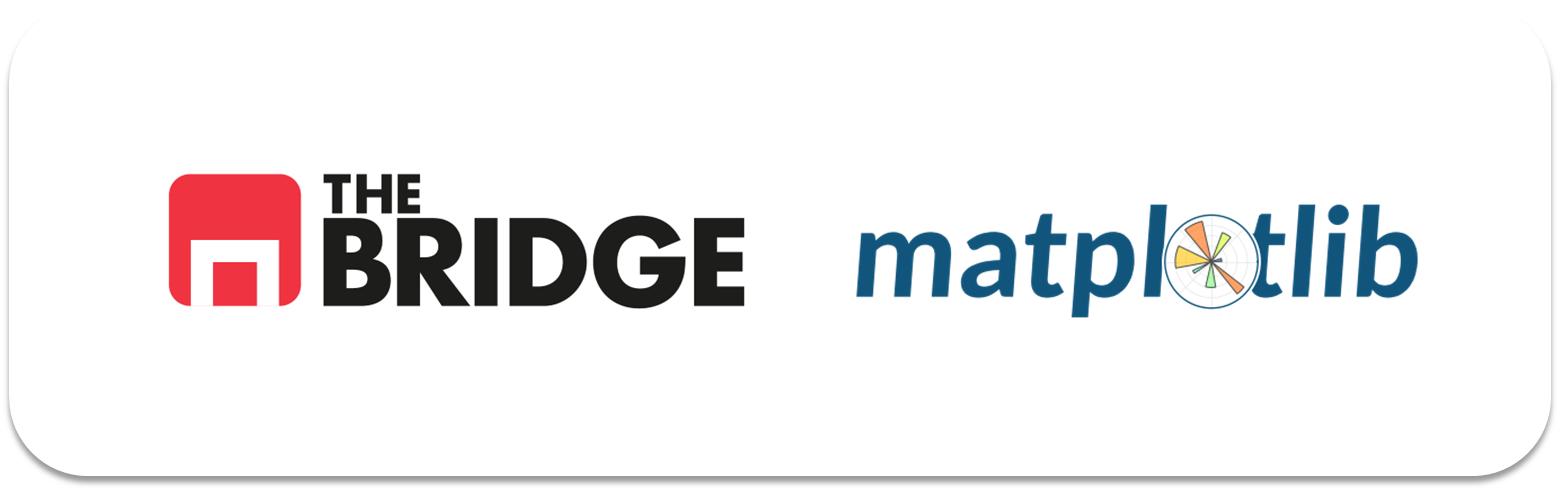

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:
df = pd.read_csv("./data/california_cities.csv")
df.head()

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


In [3]:
df = df.dropna()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 427 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          427 non-null    int64  
 1   city                427 non-null    object 
 2   latd                427 non-null    float64
 3   longd               427 non-null    float64
 4   elevation_m         427 non-null    float64
 5   elevation_ft        427 non-null    float64
 6   population_total    427 non-null    int64  
 7   area_total_sq_mi    427 non-null    float64
 8   area_land_sq_mi     427 non-null    float64
 9   area_water_sq_mi    427 non-null    float64
 10  area_total_km2      427 non-null    float64
 11  area_land_km2       427 non-null    float64
 12  area_water_km2      427 non-null    float64
 13  area_water_percent  427 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 50.0+ KB


#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center"). (Colores: azul, gris, aceituna, marrón, con trasparencia)  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Bradley Hand ITC", tamaño 18, color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion.
4. El boxplot de la altura de las ciudades.

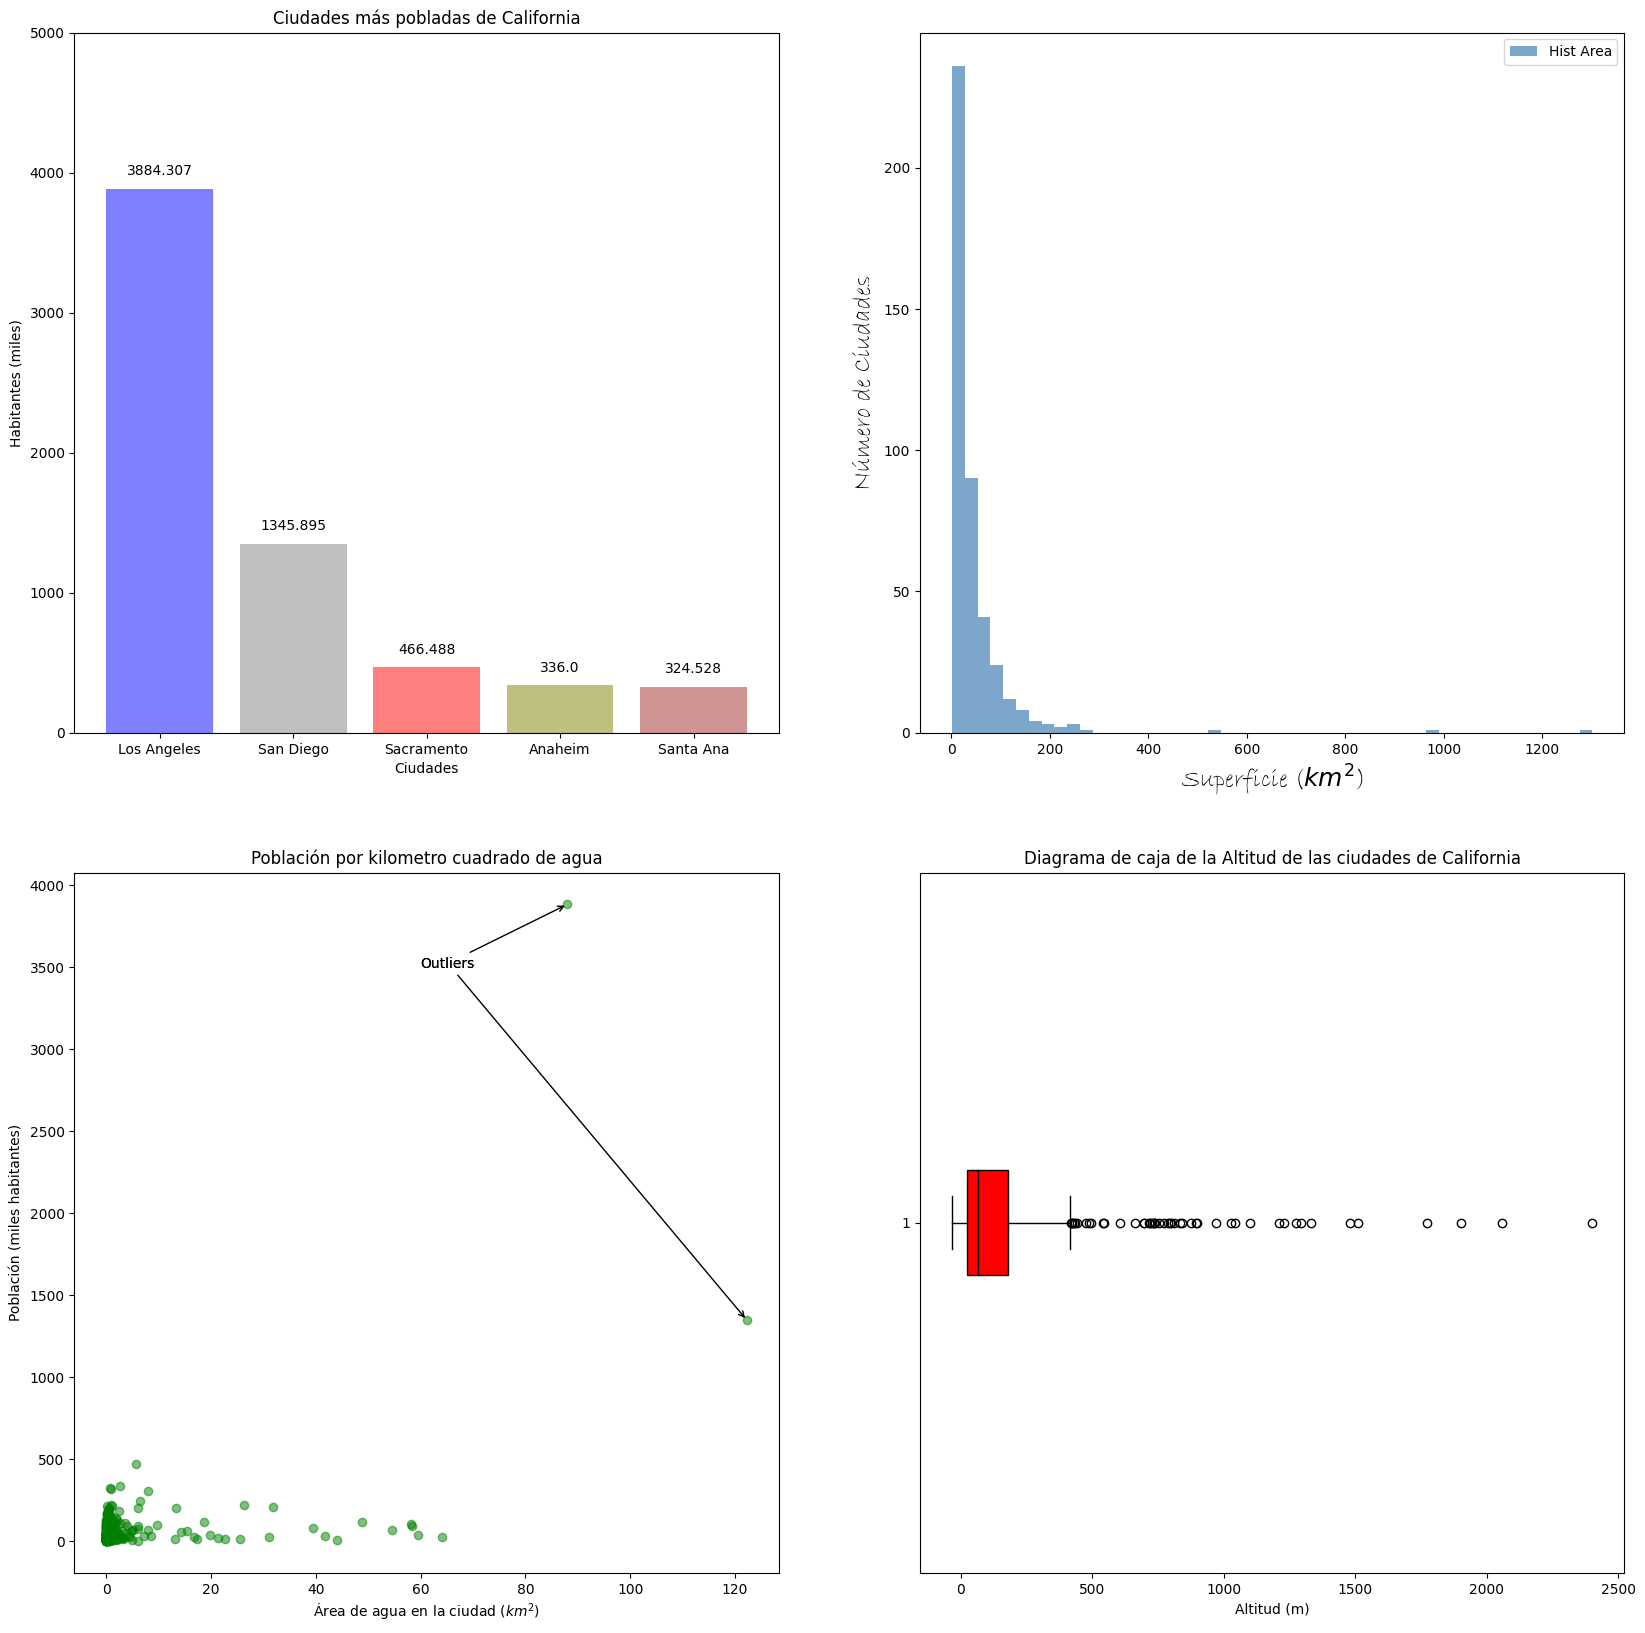

In [5]:
ciudades_pobladas= df.sort_values(by = "population_total", ascending = False).head(5)
ciudades_pobladas["population_total"]= ciudades_pobladas["population_total"]/1000



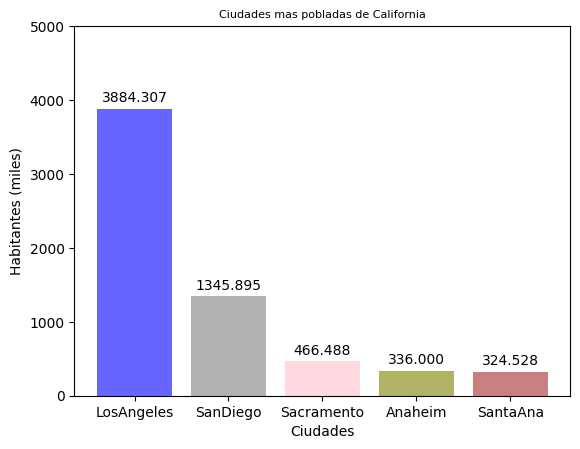

In [6]:
colours = ["blue","grey","pink", "olive", "brown"]
bars = plt.bar(ciudades_pobladas["city"],ciudades_pobladas["population_total"], color= colours, alpha =0.6)
plt.ylabel("Habitantes (miles)")
plt.xlabel("Ciudades")
plt.ylim(0,5000)
plt.title("Ciudades mas pobladas de California", size = 8)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   
        height + 50,                         
        f"{height:.3f}",                     
        ha='center', va='bottom', fontsize=10)

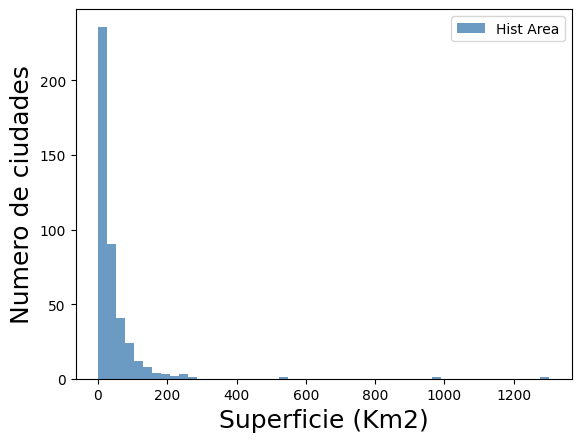

In [7]:
# no tengo ese tipo de letra, usaré este que es el unico que me acepta
plt.hist(df["area_total_km2"], bins = 50,  color = "steelblue", alpha = 0.8)
plt.ylabel("Numero de ciudades",fontsize = 18, fontfamily="DejaVu Sans")
plt.xlabel("Superficie (Km2)",fontsize = 18, fontfamily="DejaVu Sans")
plt.legend(["Hist Area"]);

In [8]:
df[df["area_water_km2"]>80]

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
239,239,LosAngeles,34.050,-118.2500,71.0,2.0,3884307,503.0,469.00,34.00,1302.00,1214.00,88.00,6.70
367,367,SanDiego,32.715,-117.1625,6.0,3.0,1345895,372.4,325.19,47.21,964.51,842.23,122.27,12.68


Text(65, 3500, 'outliers')

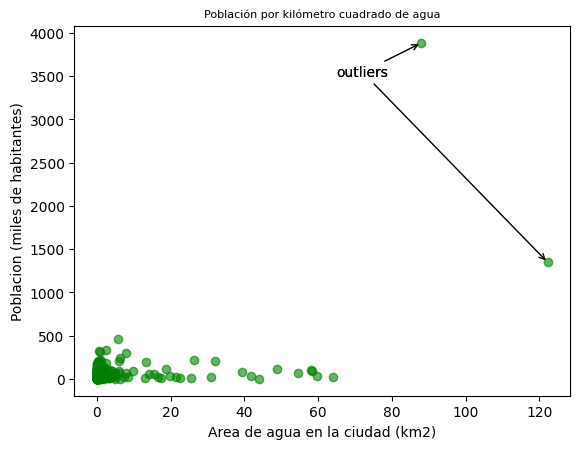

In [9]:
plt.scatter(df["area_water_km2"], df["population_total"]/1000, color = "green", alpha = 0.6)
plt.ylabel("Poblacion (miles de habitantes)")
plt.xlabel("Area de agua en la ciudad (km2)")
plt.title("Población por kilómetro cuadrado de agua", size = 8)

props = {
    "arrowstyle":"->",
    "connectionstyle":"arc3"
}
plt.annotate("outliers", xy = (122.27,1345.895), xytext = (65,3500), arrowprops=props)
plt.annotate("outliers", xy = (88,3884.307), xytext = (65,3500), arrowprops=props)

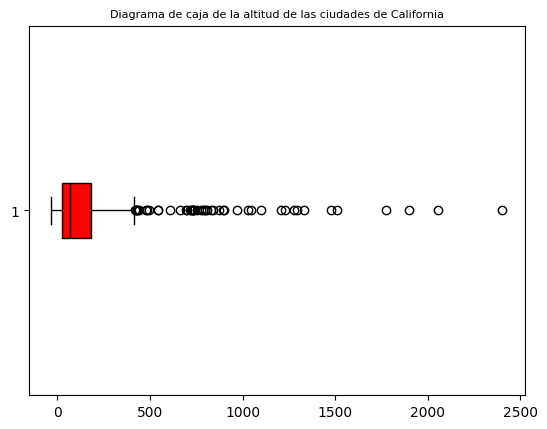

In [10]:

plt.boxplot(df["elevation_m"], vert = False, patch_artist=True, boxprops=dict(facecolor="red", linewidth=1), medianprops=dict(color="black", linewidth=1))
plt.title("Diagrama de caja de la altitud de las ciudades de California", size = 8);

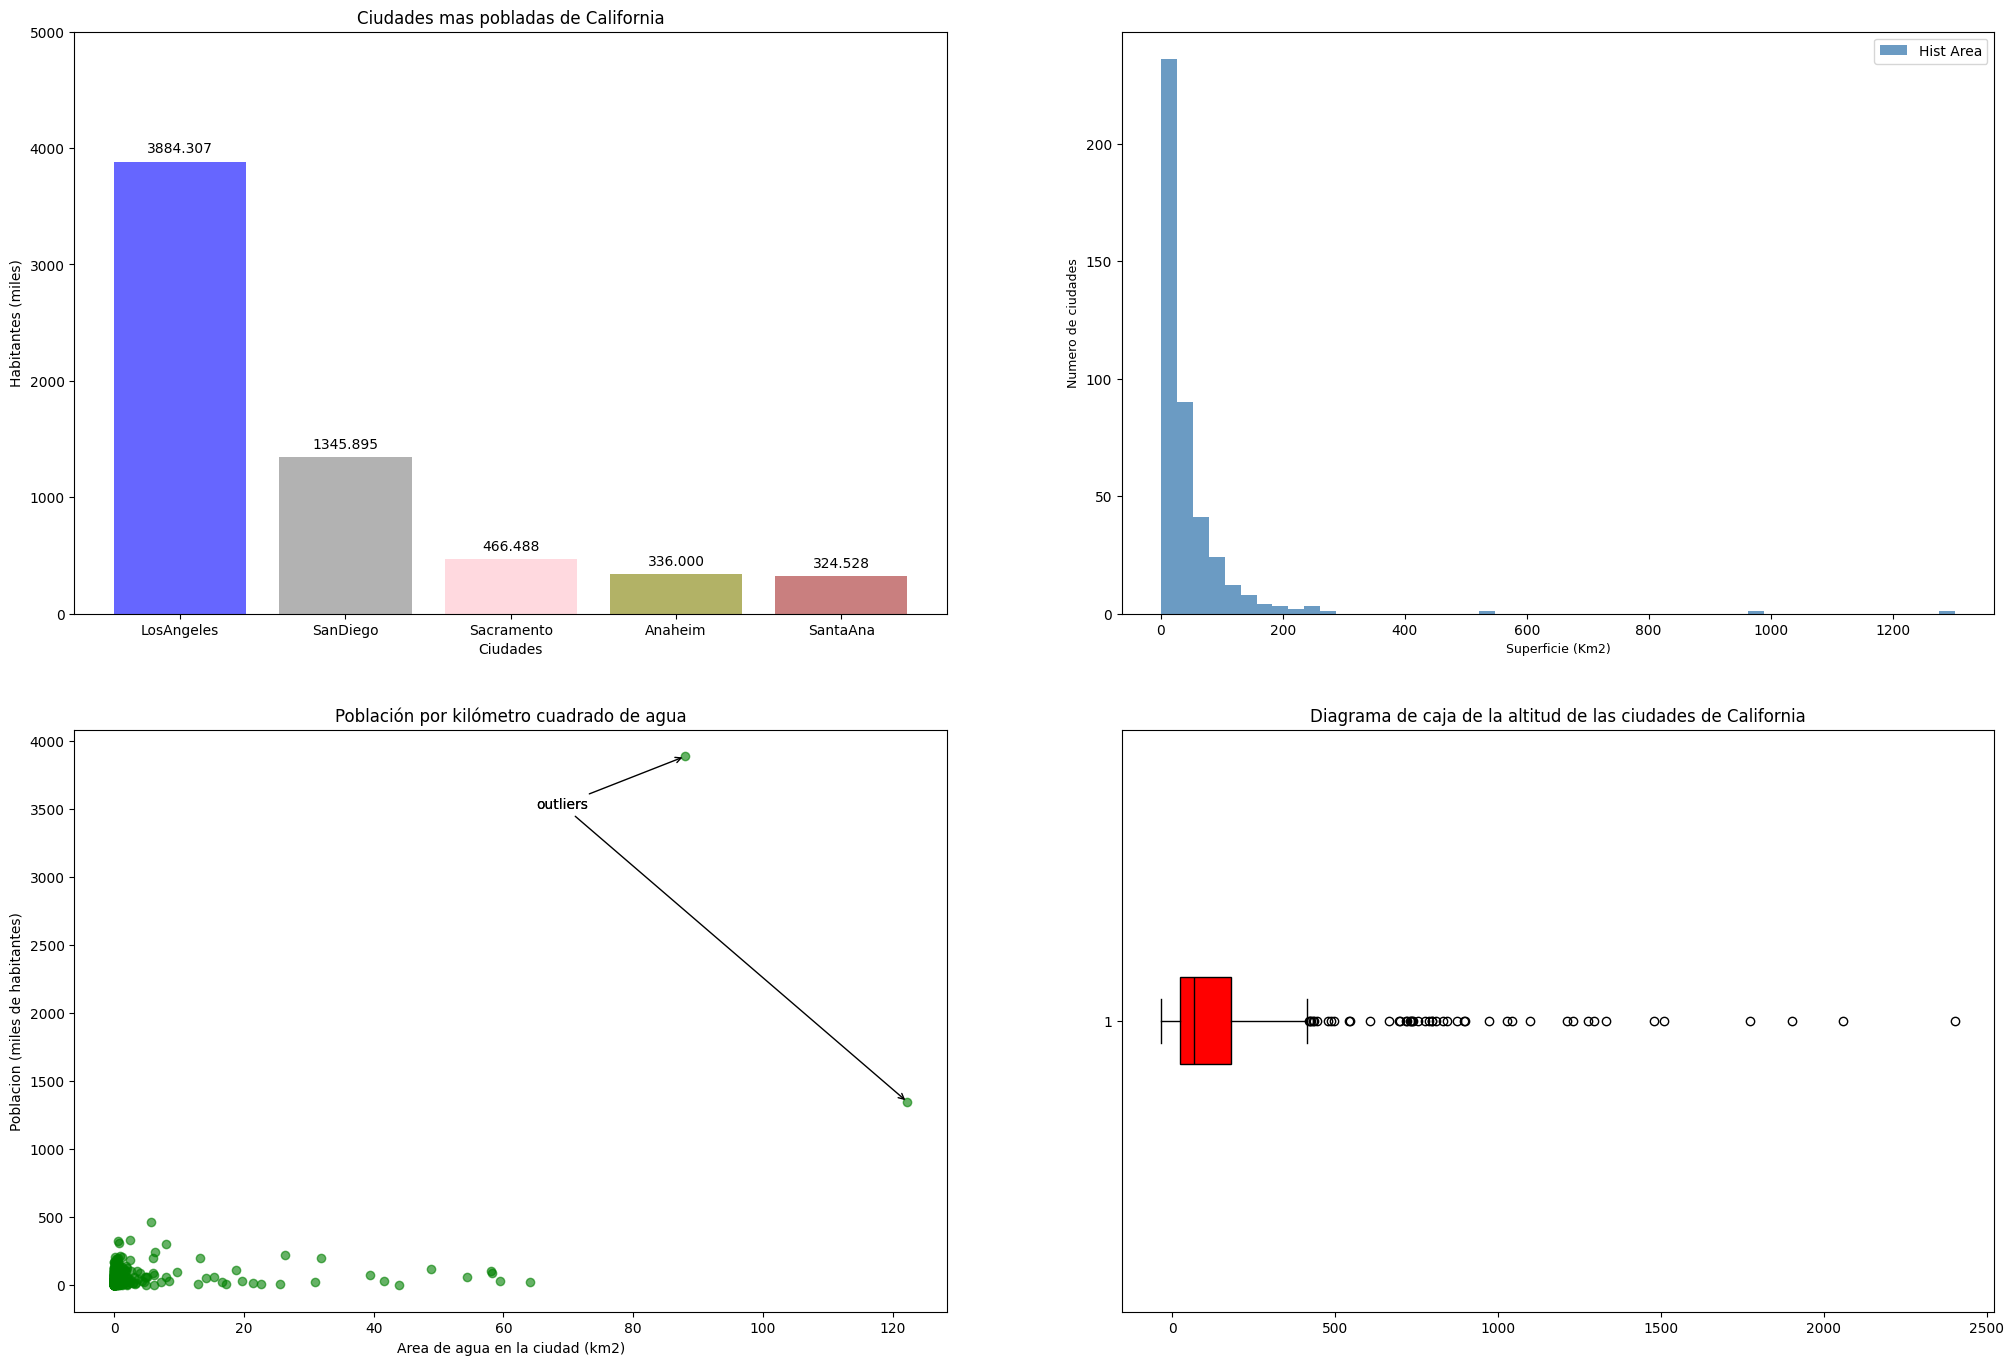

In [28]:
fig, axs = plt.subplots(2, 2, figsize=(24, 16))
plt.subplots_adjust(left=0.1,   
                    right=0.9,  
                    bottom=0.1, 
                    top=0.9,   
                    wspace=0.4, 
                    hspace=0.5) 
fig.subplots_adjust(wspace=0.2, hspace=0.2)

colours = ["blue","grey","pink", "olive", "brown"]
bars = axs[0,0].bar(ciudades_pobladas["city"],ciudades_pobladas["population_total"], color= colours, alpha =0.6)
axs[0,0].set_ylabel("Habitantes (miles)")
axs[0,0].set_xlabel("Ciudades")
axs[0,0].set_ylim(0,5000)
axs[0,0].set_title("Ciudades mas pobladas de California", size = 12)
for bar in bars:
    height = bar.get_height()
    axs[0,0].text(
        bar.get_x() + bar.get_width() / 2,   
        height + 50,                         
        f"{height:.3f}",                     
        ha='center', va='bottom', fontsize=10)
    
axs[0,1].hist(df["area_total_km2"], bins = 50,  color = "steelblue", alpha = 0.8)
axs[0,1].set_ylabel("Numero de ciudades",fontsize = 9, fontfamily="DejaVu Sans")
axs[0,1].set_xlabel("Superficie (Km2)",fontsize = 9, fontfamily="DejaVu Sans")
axs[0,1].legend(["Hist Area"])

axs[1,0].scatter(df["area_water_km2"], df["population_total"]/1000, color = "green", alpha = 0.6)
axs[1,0].set_ylabel("Poblacion (miles de habitantes)")
axs[1,0].set_xlabel("Area de agua en la ciudad (km2)")
axs[1,0].set_title("Población por kilómetro cuadrado de agua", size = 12)

props = {
    "arrowstyle":"->",
    "connectionstyle":"arc3"
}
axs[1,0].annotate("outliers", xy = (122.27,1345.895), xytext = (65,3500), arrowprops=props)
axs[1,0].annotate("outliers", xy = (88,3884.307), xytext = (65,3500), arrowprops=props)

axs[1,1].boxplot(df["elevation_m"], vert = False, patch_artist=True, boxprops=dict(facecolor="red", linewidth=1), medianprops=dict(color="black", linewidth=1))
axs[1,1].set_title("Diagrama de caja de la altitud de las ciudades de California", size = 12);



#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [29]:
fig.savefig("practica_obligatoria.png", dpi=300, bbox_inches='tight')